# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Experiment 1: ON Edges | Michael Zhou | Georgia Tech ECE**

This notebook tests whether connectome-constrained networks produce geometrically distinct
population codes compared to randomly initialized networks with the same architecture —
using representational similarity analysis (RSA) applied to the Flyvis Drosophila visual
system model (Lappalainen et al. 2024, *Nature*).

Stimuli: 12 ON moving edges at 30° increments.

**Key question:** Does biological wiring produce a representational geometry that random wiring cannot replicate? If yes, representational geometry is a candidate fidelity metric for connectome-scale neural emulations.

**References**
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems
  Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews
  Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*.
  https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [1]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

Cloning into 'flyvis'...
remote: Enumerating objects: 5230, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 5230 (delta 181), reused 155 (delta 122), pack-reused 4983 (from 3)
Receiving objects: 100% (5230/5230), 188.39 MiB | 16.95 MiB/s, done.
Resolving deltas: 100% (2675/2675), done.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.4 MB/s et

## Experiment
**Stimuli:** 12 ON moving edges at 30° increments (0° through 330°)

**Networks:**
- *Connectome-constrained (CC):* 50 models from the pretrained Flyvis ensemble
  (indices `000–009` within `flow/0000`, pre-sorted by task error), trained to
  perform optic flow estimation on naturalistic video with connectome-fixed
  architecture (734 free parameters)
- *Random baseline:* Same 50 model architectures with sign-preserving weight
  shuffles. Three strategies were evaluated:
  1. **Full Shiu-style shuffle (primary):** all 734 free parameters shuffled;
     stability-constrained sampling rejects configurations with non-finite
     activations and resamples up to 100 times per model. This is the canonical
     baseline.
  2. Synapse-only shuffle: only the 604 unitary synapse scaling factors
     (`edges_syn_strength`) shuffled, preserving trained time constants and
     resting potentials — per Lappalainen et al. (2024) Methods, time constants
     are clamped during training to prevent instability. Used for n=50
     instability documentation runs.
  3. Matched-instability baseline: full Shiu-style shuffle without stability
     filtering; non-finite activations clamped to ±1e3 in RDM construction.
     Retained for comparison against the stability-constrained result.

**Acceptance rate (strategy 1):** [X/50 models accepted on first attempt; mean
  Y attempts per model] — reported as an estimate of the stable volume of weight
  space under full Shiu-style shuffling

**Population vectors:** Peak central-cell voltage per cell type (65-dim) in
  response to each stimulus direction

**Reproducibility:** seed=42 (`numpy`, `torch`, `torch.cuda`);
  `torch.use_deterministic_algorithms(True)`

**Metrics:**
- Cosine distance RDM — scale-invariant, captures pattern geometry
- Euclidean distance RDM — captures magnitude differences
- Spearman RDM correlation — measures similarity between CC and random geometry
- Kendall's $\tau_A$ RDM correlation — preferred for RDM data with ties
  (Nili et al. 2014); reported alongside Spearman for all CC vs random comparisons
- Within-ensemble consistency — measures stability of CC representational
  geometry across trained solutions

In [2]:
"""
Experiment 1: Representational Geometry as a Fidelity Metric
for Connectome-Constrained Neural Emulations — ON Edges

This script tests whether connectome-constrained networks (Lappalainen et al. 2024)
produce geometrically distinct population codes compared to randomly initialized
networks with the same architecture.

Experiment:
- Stimuli: 12 moving edge directions (0° through 330°, 30° increments), ON edges
- Networks: pretrained connectome-constrained ensemble (all 50) vs random baseline
- Population vectors: peak central-cell response per cell type (65-dim)
- Metrics: Euclidean distance, cosine distance, RSA (RDM correlation)

Canonical runs:
    # Primary fidelity result (n=10, full Shiu-style shuffle)
    results = run_experiment(n_models=10, randomization_strategy="full_shiu")

    # Instability documentation (n=50, synapse-only shuffle)
    results = run_experiment(n_models=50, randomization_strategy="synapse_only")

Run on Google Colab with GPU runtime after installing flyvis:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]
    !flyvis download-pretrained
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr, kendalltau
from google.colab import files

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────

import flyvis
from flyvis import results_dir, EnsembleView
from flyvis.network import NetworkView
from flyvis.datasets.moving_bar import MovingEdge
from flyvis.utils.activity_utils import LayerActivity

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)

# ── 2. STIMULUS DATASET ───────────────────────────────────────────────────────

ANGLES = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]  # 12 directions (30° increments)
INTENSITY = 1                                                        # ON edges only

dataset = MovingEdge(
    offsets=[-10, 11],
    intensities=[0, 1],              # keep both; we'll filter to intensity=1
    speeds=[19],
    height=80,
    post_pad_mode="continue",
    t_pre=1.0,
    t_post=1.0,
    dt=1 / 200,
    angles=ANGLES,
)

print(f"Dataset: {len(dataset)} samples")
print(dataset.arg_df)


# ── 3. HELPER: EXTRACT POPULATION VECTOR ─────────────────────────────────────

def get_population_vector(network_view, stimulus, dt, use_fade_in=True):
    """
    Simulate network response to a single stimulus and return
    peak central-cell voltage per cell type as a population vector.

    Args:
        network_view: flyvis NetworkView instance
        stimulus: tensor of shape (n_frames, 1, 721)
        dt: temporal resolution
        use_fade_in: whether to use fade_in_state initialization

    Returns:
        pop_vec: numpy array of shape (n_cell_types,)
        cell_types: list of cell type names
    """
    network = network_view.init_network()

    # Ensure shape is (n_frames, 1, 721) — MovingEdge returns (n_frames, 721)
    if stimulus.dim() == 2:
        stimulus = stimulus.unsqueeze(1)  # (n_frames, 721) -> (n_frames, 1, 721)

    if use_fade_in:
        initial_state = network.fade_in_state(1.0, dt, stimulus[[0]])
    else:
        initial_state = None

    with torch.no_grad():
        responses = network.simulate(
            stimulus[None], dt, initial_state=initial_state
        ).cpu()

    layer_act = LayerActivity(responses, network.connectome, keepref=True)

    # Use connectome to enumerate cell types — more reliable than central.keys()
    cell_types = [
        ct.decode() if isinstance(ct, bytes) else ct
        for ct in network.connectome.unique_cell_types[:]
    ]
    pop_vec = np.array([
        layer_act.central[ct].squeeze().numpy().max()
        for ct in cell_types
    ])
    pop_vec = np.clip(pop_vec, -1e6, 1e6)  # guard against near-overflow values
    # that pass finiteness check but cause scipy cosine distance to overflow

    # Free GPU memory after each model to avoid OOM on T4 (14.56 GiB)
    del network, responses, layer_act
    torch.cuda.empty_cache()

    return pop_vec, cell_types


# ── 4. HELPER: BUILD RDM ──────────────────────────────────────────────────────

def build_rdm(pop_matrix, metric="cosine"):
    """
    Build a representational dissimilarity matrix from a population matrix.

    Args:
        pop_matrix: numpy array of shape (n_stimuli, n_cells)
        metric: "cosine" or "euclidean"

    Returns:
        rdm: numpy array of shape (n_stimuli, n_stimuli)
    """
    # Clamp any residual inf/nan to large finite values as a defensive measure.
    # Under stability-constrained sampling, non-finite activations should not
    # reach this point; clamping is retained as a safeguard.
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)

    # Add small epsilon before cosine distance computation to prevent NaN from
    # zero-norm population vectors. A stable network can still produce an
    # all-zero response vector for a given stimulus (e.g. if the network is
    # unresponsive to that direction), which makes cosine distance undefined.
    if metric == "cosine":
        norms = np.linalg.norm(pop_matrix, axis=1, keepdims=True)
        zero_norm_rows = (norms < 1e-10).flatten()
        if np.any(zero_norm_rows):
            print(f"    WARNING: {zero_norm_rows.sum()} zero-norm population "
                  f"vectors detected — adding epsilon")
        pop_matrix = pop_matrix + 1e-10

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                if metric == "cosine":
                    rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
                else:
                    rdm[i, j] = euclidean(pop_matrix[i], pop_matrix[j])
    return rdm


# ── 5. HELPER: COMPARE RDMs ──────────────────────────────────────────────────

def rdm_similarity(rdm1, rdm2):
    """
    Compute Spearman rank correlation and Kendall's tau_A between upper
    triangles of two RDMs. Kendall's tau_A is preferred for RDM data with
    ties (Nili et al. 2014); Spearman retained for comparison.
    """
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


# ── 5b. HELPER: PERMUTATION TEST ─────────────────────────────────────────────

def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=42):
    """
    Stimulus-label randomization test for RDM correlation (Nili et al. 2014).

    Permutes rows and columns of rdm2 simultaneously to preserve RDM symmetry,
    building a null distribution of RDM correlations under the hypothesis that
    the two RDMs are unrelated. The one-sided p-value is the proportion of
    permuted correlations >= the observed correlation.

    This is the recommended fixed-effects inference procedure from Nili et al.
    (2014) when a single RDM estimate is available (rather than multiple subjects).

    Args:
        rdm1: numpy array of shape (n_stimuli, n_stimuli) — reference RDM
        rdm2: numpy array of shape (n_stimuli, n_stimuli) — candidate RDM
              (stimulus labels of this RDM are permuted)
        n_permutations: number of permutations (default: 10000)
        seed: random seed for reproducibility

    Returns:
        obs_r:    observed Spearman correlation
        p_r:      permutation p-value for Spearman
        obs_tau:  observed Kendall tau_A
        p_tau:    permutation p-value for Kendall tau_A
        null_r:   null distribution of Spearman correlations
        null_tau: null distribution of Kendall tau_A values
    """
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)

    # Observed correlations
    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])

    # Null distribution via stimulus-label permutation
    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)

    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_perm = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_perm[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_perm[idx])

    # One-sided p-value: proportion of null >= observed
    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)

    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


# ── 6. HELPER: RANDOM BASELINE NETWORK ───────────────────────────────────────

def randomize_weights(network, strategy="full_shiu"):
    """
    Randomize network weights using the specified strategy, preserving E/I
    sign structure throughout.

    Args:
        network: Flyvis network instance
        strategy: "full_shiu"    — shuffle all 734 free parameters (resting
                                   potentials, time constants, synapse scaling
                                   factors). Used for n=10 primary fidelity runs.
                                   Stability-constrained: r = 0.749, τ = 0.552 (p < 0.0001).
                                   Matched-instability:   r = 0.757, τ = 0.562 (p < 0.0001).
                  "synapse_only" — shuffle only the 604 unitary synapse scaling
                                   factors (edges_syn_strength), preserving
                                   trained time constants and resting potentials.
                                   Per Lappalainen et al. (2024) Methods, time
                                   constants are clamped during training to prevent
                                   instability. Used for n=50 instability runs.

    Returns:
        network with randomized weights
    """
    with torch.no_grad():
        for name, param in network.named_parameters():
            if param.requires_grad:
                if strategy == "synapse_only":
                    if "time_const" in name or "nodes_bias" in name:
                        continue
                signs = torch.sign(param.data)
                abs_vals = param.data.abs()
                flat = abs_vals.flatten()
                perm = torch.randperm(flat.shape[0])
                shuffled = flat[perm].reshape(abs_vals.shape)
                param.data = signs * shuffled
    return network


def randomize_weights_stable(network_view, strategy="full_shiu",
                              max_attempts=50, stimulus=None, dt=None):
    """
    Repeatedly randomize network weights until a stable configuration is found.

    On each attempt, reloads the network from checkpoint (ensuring a clean
    trained starting point), randomizes weights via randomize_weights(), and
    runs a single forward pass to check for finite outputs. The first
    configuration that produces all-finite activations is returned.

    This is the stability-constrained alternative to the matched-instability
    baseline (which accepts unstable configurations and clamps them in
    build_rdm). Using this function ensures every random baseline RDM entry
    reflects a genuine population response rather than a numerical artifact.

    Args:
        network_view: flyvis NetworkView instance — used to reload the network
                      from checkpoint on each attempt via init_network()
        strategy:     weight randomization strategy passed to randomize_weights()
                      ("full_shiu" or "synapse_only")
        max_attempts: maximum number of randomization attempts before giving up
                      (default: 50). If all attempts fail, returns (None, max_attempts).
        stimulus:     torch.Tensor of shape (n_frames, 721) or (n_frames, 1, 721)
                      used for the stability check forward pass. Should be a
                      representative stimulus — typically the first stimulus in
                      the experimental set.
        dt:           temporal resolution of the simulation (e.g. dataset.dt)

    Returns:
        network:         flyvis network instance with stable randomized weights,
                         or None if all attempts failed
        attempts_needed: number of attempts required (1-indexed), or max_attempts
                         if all attempts failed. Log this across models to estimate
                         the acceptance rate of stable configurations in weight space.

    Notes:
        - GPU memory is cleared after each failed attempt via torch.cuda.empty_cache()
        - E/I sign structure is preserved throughout (inherited from randomize_weights)
        - A single forward pass on one stimulus is used for the stability check as a
          necessary but not sufficient condition; the pop_vec clip (±1e6) in the
          collection loop guards against near-overflow on stimuli not covered by the
          check stimulus
    """
    for attempt in range(max_attempts):
        network = network_view.init_network()
        network = randomize_weights(network, strategy)
        with torch.no_grad():
            if stimulus.dim() == 2:
                stim = stimulus.unsqueeze(1)
            else:
                stim = stimulus
            try:
                initial_state = network.fade_in_state(1.0, dt, stim[[0]])
                out = network.simulate(stim[None], dt, initial_state=initial_state)
                out_np = out.cpu().numpy()
                if torch.all(torch.isfinite(out)) and np.all(np.abs(out_np) < 1e6):
                    # isfinite alone is insufficient: very large but technically finite values
                    # (e.g. 1e38) pass the finiteness check but overflow scipy's float64
                    # cosine computation (uv / sqrt(uu * vv)). The 1e6 threshold is
                    # conservative — legitimate LIF voltages are O(mV), so anything above
                    # 1e3 is already pathological.
                    return network, attempt + 1  # attempts_needed is 1-indexed
            except Exception:
                pass
        torch.cuda.empty_cache()
    return None, max_attempts  # all attempts exhausted


# ── 7. MAIN EXPERIMENT ────────────────────────────────────────────────────────

def run_experiment(n_models=50, randomization_strategy="full_shiu",
                   n_permutations=10000):
    """
    Run the ON edges RSA experiment.

    Args:
        n_models: number of models to use (set to 1 for debugging, 50 for full run)
        randomization_strategy: "full_shiu" or "synapse_only" (see randomize_weights)
        n_permutations: number of permutations for stimulus-label randomization test
                        (Nili et al. 2014). Set to 0 to skip permutation testing.
    """
    print("\n" + "="*60)
    print("FLYVIS RSA — ON EDGES")
    print("="*60)
    print(f"Random seed: {SEED}")
    print(f"Randomization strategy: {randomization_strategy}")

    # ── 7a. Load ensemble ─────────────────────────────────────────────────────
    print("\nLoading ensemble...")
    ensemble = EnsembleView(results_dir / "flow/0000")
    best_indices = list(range(n_models))  # 000-049 pre-sorted best to worst
    print(f"Using {n_models} model(s): indices {best_indices}")

    # ── 7b. Get stimuli (ON edges, 12 directions) ─────────────────────────────
    on_edge_indices = [
        i for i, row in dataset.arg_df.iterrows()
        if row["intensity"] == INTENSITY
    ]
    print(f"\nStimulus conditions (ON edges, {len(on_edge_indices)} directions):")
    print(dataset.arg_df.iloc[on_edge_indices])

    n_stim = len(on_edge_indices)

    # ── 7c. Connectome-constrained: collect population vectors ────────────────
    print("\n--- CONNECTOME-CONSTRAINED NETWORKS ---")
    cc_pop_matrices = []
    cell_types = None

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        print(f"  Model {rank+1}/{n_models} ({model_path.name})...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            pop_vec, cell_types = get_population_vector(nv, stimulus, dataset.dt)
            pop_vecs.append(pop_vec)

        pop_matrix = np.stack(pop_vecs, axis=0)  # (12, n_cell_types)
        cc_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del nv
        torch.cuda.empty_cache()

    print(f"\n  Cell types ({len(cell_types)}): {cell_types[:5]}...")

    # ── 7d. Random baseline: stability-constrained sampling ──────────────────
    print("\n--- RANDOM BASELINE NETWORKS (stability-constrained) ---")
    rand_pop_matrices = []
    attempts_log = []  # initialized outside the loop

    # Use first ON-edge stimulus for stability check
    _check_stim = dataset[on_edge_indices[0]]
    if not isinstance(_check_stim, torch.Tensor):
        _check_stim = torch.tensor(_check_stim, dtype=torch.float32)

    MAX_ATTEMPTS = 100

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)

        network, attempts_needed = randomize_weights_stable(
            nv, strategy=randomization_strategy,
            max_attempts=MAX_ATTEMPTS, stimulus=_check_stim, dt=dataset.dt
        )

        if network is None:
            print(f"  WARNING: model {rank+1} failed all {MAX_ATTEMPTS} attempts — skipping")
            attempts_log.append(MAX_ATTEMPTS)
            del nv
            torch.cuda.empty_cache()
            continue

        attempts_log.append(attempts_needed)
        print(f"  Random model {rank+1}/{n_models}: accepted on attempt "
              f"{attempts_needed}/{MAX_ATTEMPTS}...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            if stimulus.dim() == 2:
                stimulus = stimulus.unsqueeze(1)

            with torch.no_grad():
                initial_state = network.fade_in_state(1.0, dataset.dt, stimulus[[0]])
                responses = network.simulate(
                    stimulus[None], dataset.dt, initial_state=initial_state
                ).cpu()
            layer_act = LayerActivity(responses, network.connectome, keepref=True)
            pop_vec = np.array([
                layer_act.central[ct].squeeze().numpy().max()
                for ct in cell_types
            ])
            pop_vec = np.clip(pop_vec, -1e6, 1e6)  # guard against near-overflow on
            # stimuli not covered by the stability check forward pass
            pop_vecs.append(pop_vec)

            del responses, layer_act
            torch.cuda.empty_cache()

        pop_matrix = np.stack(pop_vecs, axis=0)
        rand_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del network, nv
        torch.cuda.empty_cache()

    # Attempts summary
    print(f"\n--- STABILITY-CONSTRAINED SAMPLING SUMMARY ---")
    print(f"  Attempts per model: {attempts_log}")
    print(f"  Mean attempts: {np.mean(attempts_log):.1f} ± {np.std(attempts_log):.1f}")
    print(f"  Accepted: {sum(a < MAX_ATTEMPTS for a in attempts_log)}/{len(attempts_log)}")
    print(f"  First-try acceptance: {sum(a == 1 for a in attempts_log)}/{len(attempts_log)}")

    # ── 7e. Compute RDMs ──────────────────────────────────────────────────────
    print("\n--- COMPUTING RDMs ---")
    cc_rdms_cosine   = [build_rdm(m, "cosine")    for m in cc_pop_matrices]
    cc_rdms_eucl     = [build_rdm(m, "euclidean") for m in cc_pop_matrices]
    rand_rdms_cosine = [build_rdm(m, "cosine")    for m in rand_pop_matrices]
    rand_rdms_eucl   = [build_rdm(m, "euclidean") for m in rand_pop_matrices]

    stable_rand_indices = [
        i for i, m in enumerate(rand_pop_matrices)
        if np.all(np.isfinite(m))
    ]
    print(f"\n  Stable random models: {len(stable_rand_indices)} / {n_models}")
    print(f"  Unstable random models: {n_models - len(stable_rand_indices)} / {n_models}")

    rand_rdms_cosine_stable = [rand_rdms_cosine[i] for i in stable_rand_indices]
    rand_rdms_eucl_stable   = [rand_rdms_eucl[i]   for i in stable_rand_indices]

    cc_rdm_cosine_mean   = np.mean(cc_rdms_cosine,         axis=0)
    cc_rdm_eucl_mean     = np.mean(cc_rdms_eucl,            axis=0)
    rand_rdm_cosine_mean = np.mean(rand_rdms_cosine_stable, axis=0)
    rand_rdm_eucl_mean   = np.mean(rand_rdms_eucl_stable,   axis=0)

    # ── 7f. RDM similarity (CC vs random) — analytical ────────────────────────
    print("\n--- RDM SIMILARITY (Connectome-Constrained vs Random) ---")
    if len(stable_rand_indices) == 0:
        print("  No stable random models — skipping RDM similarity.")
        r_cosine = p_cosine = rk_cosine = pk_cosine = float("nan")
        r_eucl   = p_eucl   = rk_eucl   = pk_eucl   = float("nan")
    else:
        r_cosine, p_cosine, rk_cosine, pk_cosine = rdm_similarity(
            cc_rdm_cosine_mean, rand_rdm_cosine_mean)
        r_eucl, p_eucl, rk_eucl, pk_eucl = rdm_similarity(
            cc_rdm_eucl_mean, rand_rdm_eucl_mean)
    print(f"  Cosine RDM:    Spearman r = {r_cosine:.3f}, p = {p_cosine:.4f} "
          f"| Kendall τ = {rk_cosine:.3f}, p = {pk_cosine:.4f}  [analytical]")
    print(f"  Euclidean RDM: Spearman r = {r_eucl:.3f}, p = {p_eucl:.4f} "
          f"| Kendall τ = {rk_eucl:.3f}, p = {pk_eucl:.4f}  [analytical]")

    # ── 7f2. Permutation test (Nili et al. 2014 stimulus-label randomization) ─
    perm_results_cosine = None
    perm_results_eucl   = None

    if n_permutations > 0 and len(stable_rand_indices) > 0:
        print(f"\n--- PERMUTATION TEST ({n_permutations} permutations, "
              f"Nili et al. 2014) ---")

        obs_r, p_r_perm, obs_tau, p_tau_perm, null_r, null_tau = \
            permutation_test_rdm(cc_rdm_cosine_mean, rand_rdm_cosine_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Cosine RDM:    Spearman r = {obs_r:.3f}, p_perm = {p_r_perm:.4f} "
              f"| Kendall τ = {obs_tau:.3f}, p_perm = {p_tau_perm:.4f}  [permutation]")
        perm_results_cosine = dict(obs_r=obs_r, p_r=p_r_perm,
                                   obs_tau=obs_tau, p_tau=p_tau_perm,
                                   null_r=null_r, null_tau=null_tau)

        obs_r_e, p_r_e, obs_tau_e, p_tau_e, null_r_e, null_tau_e = \
            permutation_test_rdm(cc_rdm_eucl_mean, rand_rdm_eucl_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Euclidean RDM: Spearman r = {obs_r_e:.3f}, p_perm = {p_r_e:.4f} "
              f"| Kendall τ = {obs_tau_e:.3f}, p_perm = {p_tau_e:.4f}  [permutation]")
        perm_results_eucl = dict(obs_r=obs_r_e, p_r=p_r_e,
                                 obs_tau=obs_tau_e, p_tau=p_tau_e,
                                 null_r=null_r_e, null_tau=null_tau_e)

        # ── Plot null distributions ───────────────────────────────────────────
        fig_perm, axes_perm = plt.subplots(1, 2, figsize=(10, 3.5))
        fig_perm.suptitle(
            f"Permutation null distributions — ON edges "
            f"[{randomization_strategy}, n={n_models}]",
            fontsize=10
        )
        for ax, null, obs, metric in zip(
            axes_perm,
            [null_r,   null_tau],
            [obs_r,    obs_tau],
            ["Spearman r (cosine RDM)", "Kendall τ (cosine RDM)"]
        ):
            ax.hist(null, bins=50, color="steelblue", alpha=0.7,
                    label="Null distribution")
            ax.axvline(obs, color="red", linewidth=2,
                       label=f"Observed = {obs:.3f}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
        plt.tight_layout()
        fname_perm = (f"moving_edge_on_permtest_{n_models}models"
                      f"_{randomization_strategy}.png")
        fig_perm.savefig(fname_perm, dpi=150, bbox_inches="tight")
        print(f"  Saved: {fname_perm}")
        plt.show()

    elif n_permutations > 0:
        print("\n  [Permutation test skipped — no stable random models]")

    print("\n  Interpretation:")
    print("  Low r  → CC and random networks have DIFFERENT representational geometry")
    print("  High r → similar geometry (random network could substitute connectome)")

    # ── 7g. Within-ensemble consistency ───────────────────────────────────────
    print("\n--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---")
    within_corrs = []
    for i in range(len(cc_rdms_cosine)):
        for j in range(i+1, len(cc_rdms_cosine)):
            r, _, _, _ = rdm_similarity(cc_rdms_cosine[i], cc_rdms_cosine[j])
            within_corrs.append(r)
    if within_corrs:
        print(f"  Mean pairwise RDM correlation across CC models: "
              f"{np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")
    else:
        print("  (Need >1 model to compute within-ensemble consistency)")

    # ── 7h. Plot RDMs ─────────────────────────────────────────────────────────
    print("\n--- GENERATING FIGURE ---")
    angle_labels = [f"{a}°" for a in ANGLES]

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    fig.suptitle(
        "Representational Geometry: Connectome-Constrained vs Random\n"
        f"Moving edge stimuli (12 directions, 30° increments), ON edges "
        f"[{randomization_strategy}, n={n_models}]",
        fontsize=10
    )

    for ax, rdm, title in zip(
        axes,
        [cc_rdm_cosine_mean, rand_rdm_cosine_mean,
         cc_rdm_eucl_mean,   rand_rdm_eucl_mean],
        ["CC — Cosine RDM", "Random — Cosine RDM",
         "CC — Euclidean RDM", "Random — Euclidean RDM"]
    ):
        if np.ndim(rdm) < 2 or not np.any(np.isfinite(rdm)):
            ax.set_title(f"{title}\n(not renderable)", fontsize=7)
            ax.axis("off")
        else:
            im = ax.imshow(rdm, cmap="viridis", vmin=0)
            ax.set_title(title, fontsize=8)
            ax.set_xticks(range(n_stim))
            ax.set_xticklabels(angle_labels, fontsize=6, rotation=90)
            ax.set_yticks(range(n_stim))
            ax.set_yticklabels(angle_labels, fontsize=6)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = f"moving_edge_on_rdms_{n_models}models_{randomization_strategy}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved: {fname}")
    plt.show()

    # ── 7i. Summary ───────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  N stimuli:              {n_stim} (ON edges, 12 directions)")
    print(f"  N models:               {n_models}")
    print(f"  Randomization strategy: {randomization_strategy}")
    print(f"  Population vec dim:     {cc_pop_matrices[0].shape[1]} (cell types)")
    print(f"  Cosine RDM corr (CC vs random):    Spearman r = {r_cosine:.3f} "
          f"| Kendall τ = {rk_cosine:.3f}  [analytical]")
    if perm_results_cosine:
        print(f"                                     Spearman r = "
              f"{perm_results_cosine['obs_r']:.3f}, "
              f"p_perm = {perm_results_cosine['p_r']:.4f} "
              f"| Kendall τ = {perm_results_cosine['obs_tau']:.3f}, "
              f"p_perm = {perm_results_cosine['p_tau']:.4f}  [permutation]")
    print(f"  Euclidean RDM corr (CC vs random): Spearman r = {r_eucl:.3f} "
          f"| Kendall τ = {rk_eucl:.3f}  [analytical]")
    if within_corrs:
        print(f"  Within-CC consistency:             "
              f"r = {np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")

    return {
        "cc_rdm_cosine":    cc_rdm_cosine_mean,
        "rand_rdm_cosine":  rand_rdm_cosine_mean,
        "cc_rdm_eucl":      cc_rdm_eucl_mean,
        "rand_rdm_eucl":    rand_rdm_eucl_mean,
        "r_cosine":  r_cosine,  "p_cosine":  p_cosine,
        "rk_cosine": rk_cosine, "pk_cosine": pk_cosine,
        "r_eucl":    r_eucl,    "p_eucl":    p_eucl,
        "rk_eucl":   rk_eucl,   "pk_eucl":   pk_eucl,
        "perm_cosine": perm_results_cosine,
        "perm_eucl":   perm_results_eucl,
        "within_corrs": within_corrs,
        "cell_types":   cell_types,
        "randomization_strategy": randomization_strategy,
    }

building stimuli:   0%|          | 0/24 [00:00<?, ?it/s]

Dataset: 24 samples
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210     80          1  0.428766     19
16    240     80          0  0.428766     19
17    240     80          1  0.428766     19
18    270     80          0  0.428766     19
19    270     80          1  0.428766     19
20    300     80          0  0.4287

## Run Experiment


FLYVIS RSA — ON EDGES
Random seed: 42
Randomization strategy: full_shiu

Loading ensemble...


Loading ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

Using 50 model(s): indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Stimulus conditions (ON edges, 12 directions):
    angle  width  intensity    t_stim  speed
1       0     80          1  0.428766     19
3      30     80          1  0.428766     19
5      60     80          1  0.428766     19
7      90     80          1  0.428766     19
9     120     80          1  0.428766     19
11    150     80          1  0.428766     19
13    180     80          1  0.428766     19
15    210     80          1  0.428766     19
17    240     80          1  0.428766     19
19    270     80          1  0.428766     19
21    300     80          1  0.428766     19
23    330     80          1  0.428766     19

--- CONNECTOME-CONSTRAINED NETWORKS ---
  Model 1/50 (000)... 

done. Pop vec shape: (12, 65)
  Model 2/50 (001)... 

done. Pop vec shape: (12, 65)
  Model 3/50 (002)... 

...

done. Pop vec shape: (12, 65)
  Model 46/50 (045)... 

done. Pop vec shape: (12, 65)
  Model 47/50 (046)... 

done. Pop vec shape: (12, 65)
  Model 48/50 (047)... 

done. Pop vec shape: (12, 65)
  Model 49/50 (048)... 

done. Pop vec shape: (12, 65)
  Model 50/50 (049)... done. Pop vec shape: (12, 65)

  Cell types (65): ['R1', 'R2', 'R3', 'R4', 'R5']...

--- RANDOM BASELINE NETWORKS (stability-constrained) ---
  Random model 1/50: accepted on attempt 1/100... done. Pop vec shape: (12, 65)
  Random model 2/50: accepted on attempt 6/100... done. Pop vec shape: (12, 65)
  Random model 3/50: accepted on attempt 2/100... done. Pop vec shape: (12, 65)
  Random model 4/50: accepted on attempt 12/100... done. Pop vec shape: (12, 65)
  Random model 5/50: accepted on attempt 6/100... done. Pop vec shape: (12, 65)
  Random model 6/50: accepted on attempt 9/100... done. Pop vec shape: (12, 65)
  Random model 7/50: accepted on attempt 5/100... done. Pop vec shape: (12, 65)
  Random model 8/50: accepted on attempt 16/100... done. Pop vec shape: (12, 65)
  Random model 9/50: accepted on attempt 18/100... done. Pop vec shape: (12, 65)
  Random model 10/50: accepted on attempt 36/100... done. Pop vec shape: (12, 65)


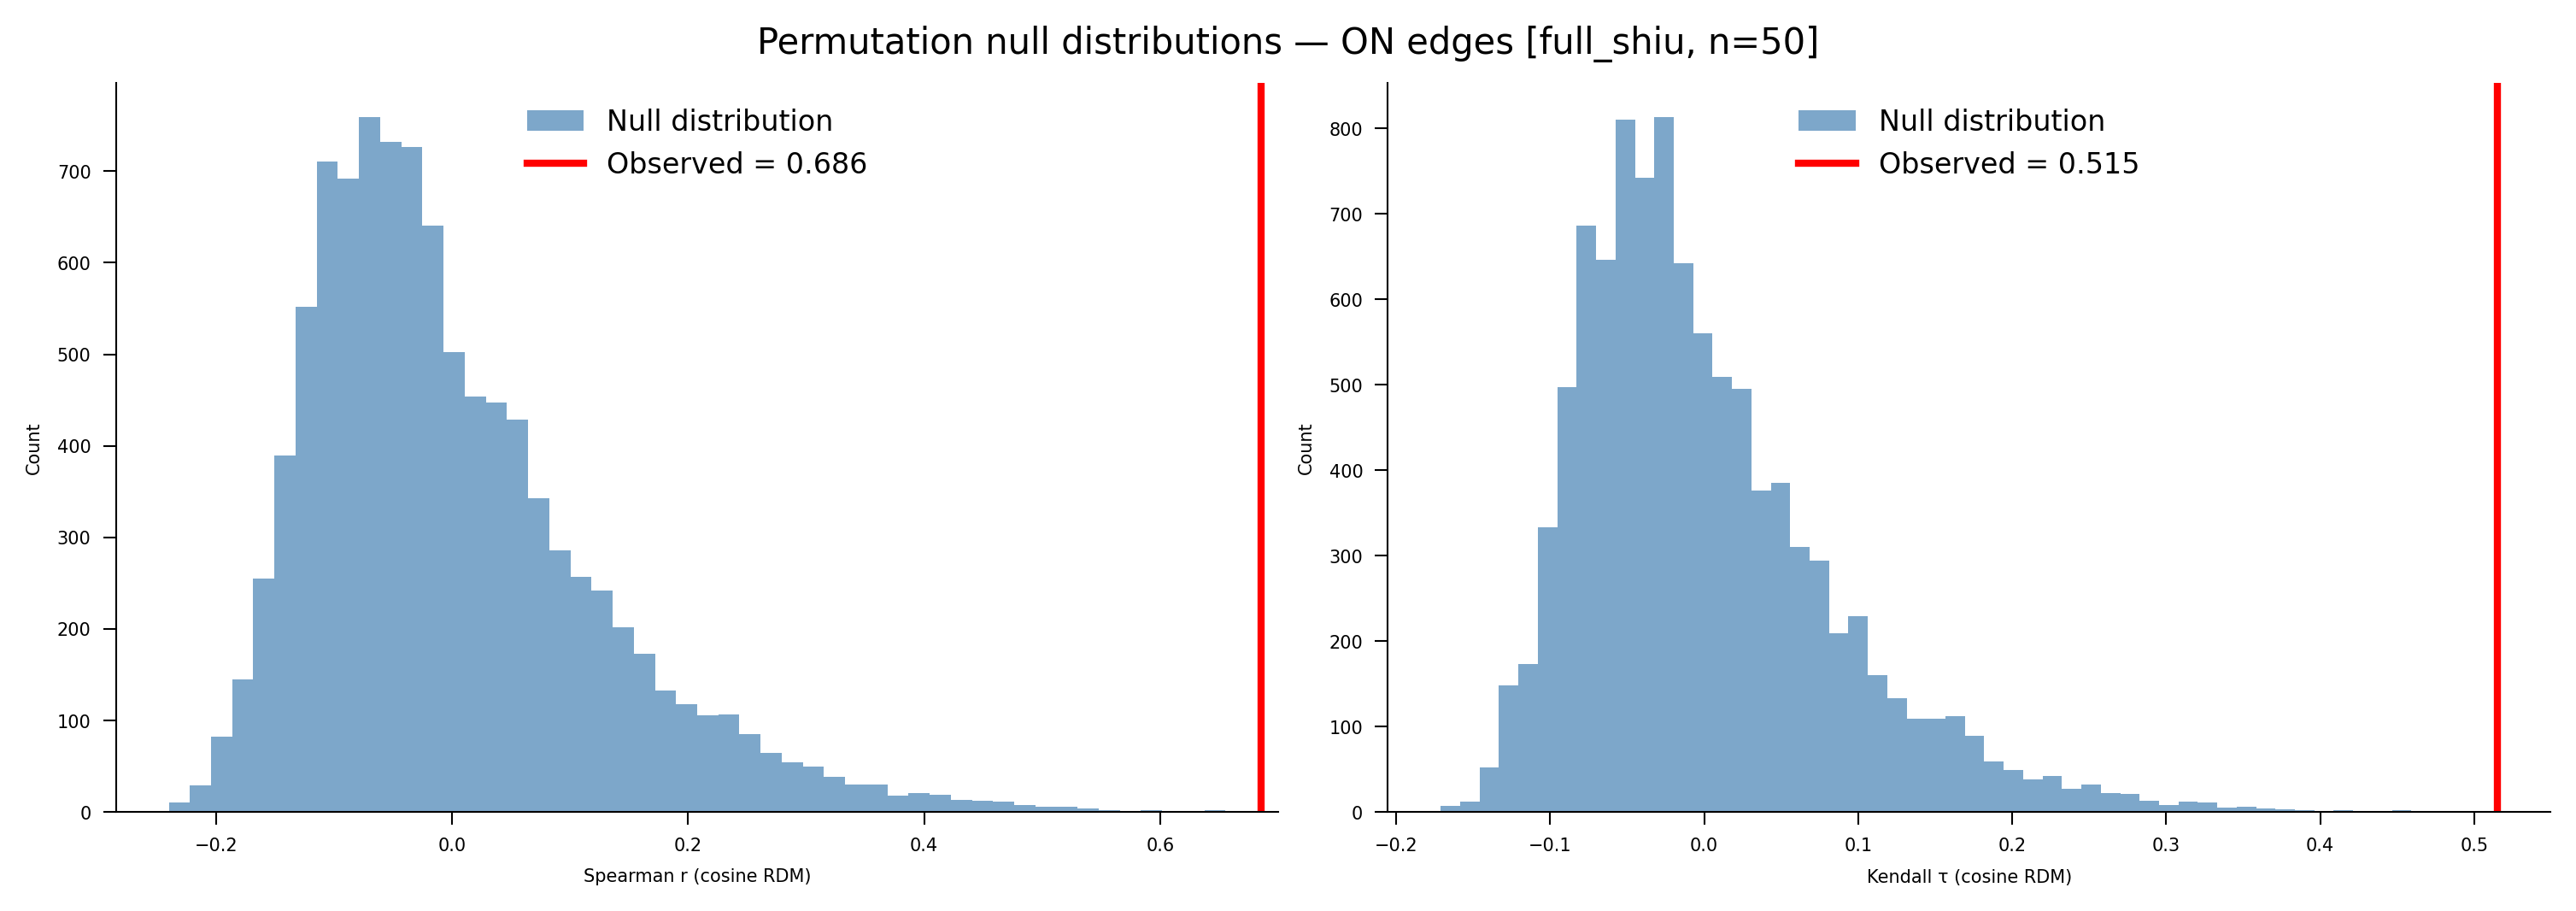


  Interpretation:
  Low r  → CC and random networks have DIFFERENT representational geometry
  High r → similar geometry (random network could substitute connectome)

--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---
  Mean pairwise RDM correlation across CC models: 0.721 ± 0.150

--- GENERATING FIGURE ---
  Saved: moving_edge_on_rdms_50models_full_shiu.png


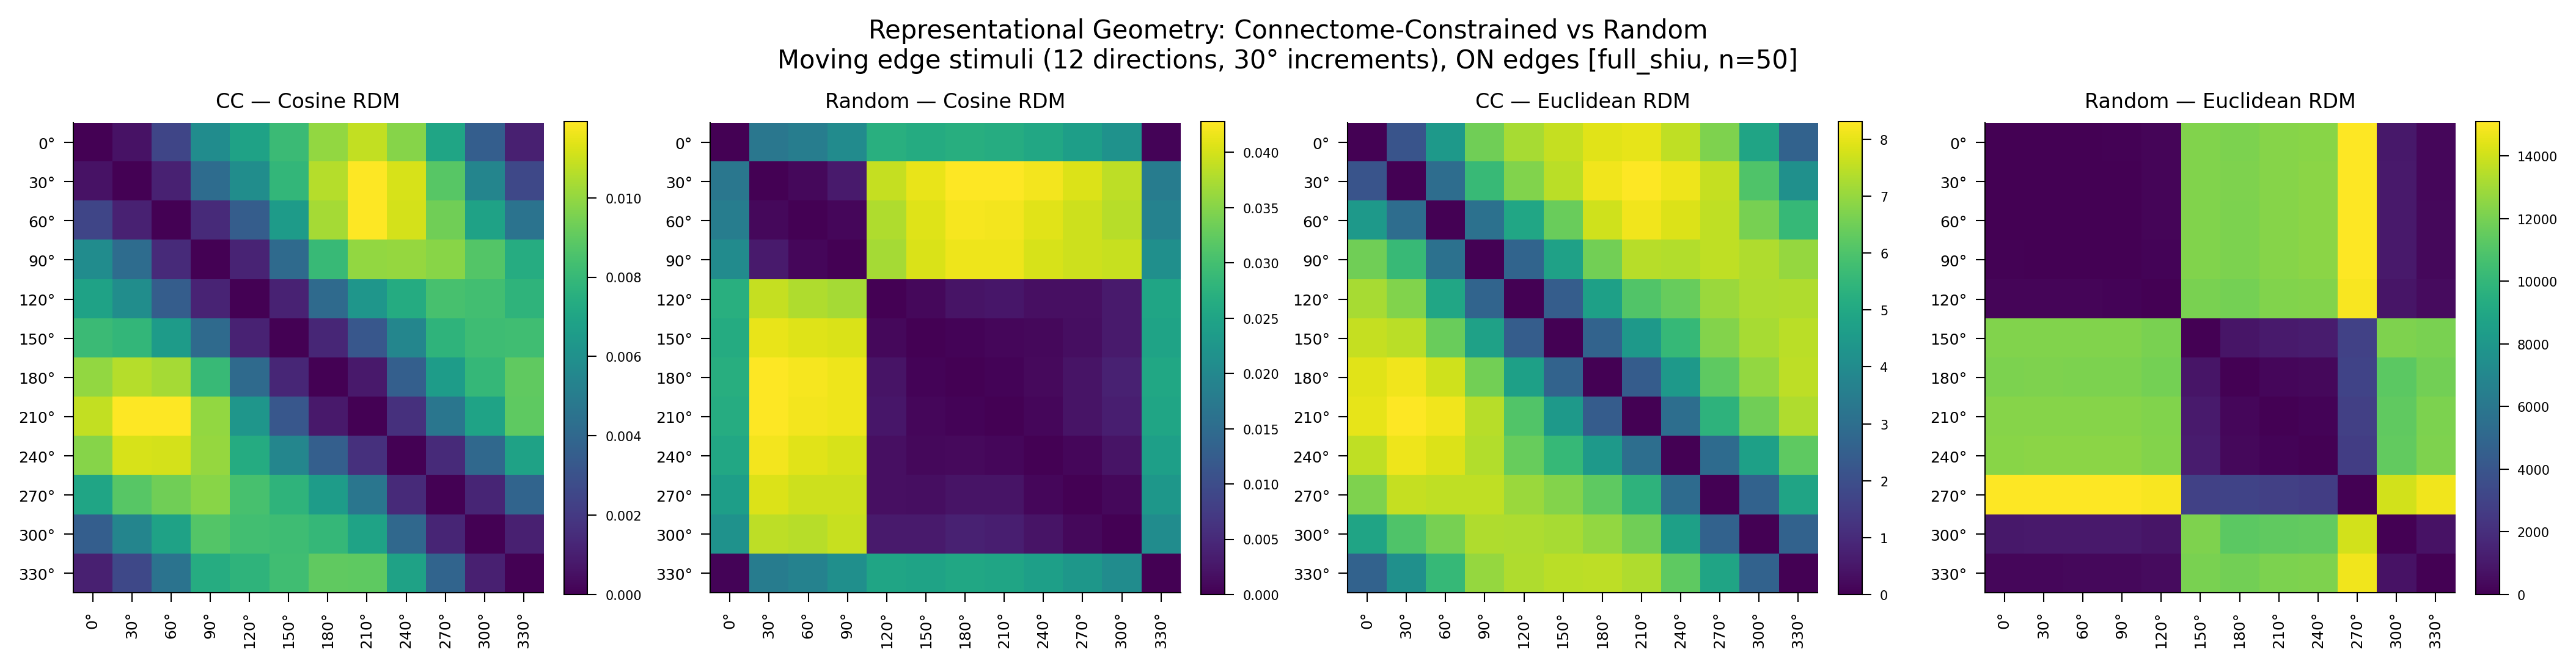


SUMMARY
  N stimuli:              12 (ON edges, 12 directions)
  N models:               50
  Randomization strategy: full_shiu
  Population vec dim:     65 (cell types)
  Cosine RDM corr (CC vs random):    Spearman r = 0.686 | Kendall τ = 0.515  [analytical]
                                     Spearman r = 0.686, p_perm = 0.0000 | Kendall τ = 0.515, p_perm = 0.0000  [permutation]
  Euclidean RDM corr (CC vs random): Spearman r = 0.588 | Kendall τ = 0.418  [analytical]
  Within-CC consistency:             r = 0.721 ± 0.150


{'cc_rdm_cosine': array([[0.        , 0.00057731, 0.00247404, 0.00579521, 0.00689483,
         0.0081323 , 0.00998286, 0.01085062, 0.00975791, 0.00702922,
         0.00355459, 0.00104214],
        [0.00057731, 0.        , 0.00110193, 0.00420906, 0.00586209,
         0.00788093, 0.01059998, 0.01189057, 0.01122482, 0.00883941,
         0.00545029, 0.00259838],
        [0.00247404, 0.00110193, 0.        , 0.00143891, 0.00349744,
         0.00654119, 0.01032295, 0.01192651, 0.01115547, 0.00935389,
         0.00685834, 0.00454546],
        [0.00579521, 0.00420906, 0.00143891, 0.        , 0.00117123,
         0.00414585, 0.00805363, 0.00998056, 0.01003143, 0.00979212,
         0.00871474, 0.00738715],
        [0.00689483, 0.00586209, 0.00349744, 0.00117123, 0.        ,
         0.00115566, 0.00411725, 0.00624584, 0.00735604, 0.00847542,
         0.00831804, 0.00776992],
        [0.0081323 , 0.00788093, 0.00654119, 0.00414585, 0.00115566,
         0.        , 0.00126732, 0.0032567 , 0.0054920

In [3]:
results = run_experiment(n_models=50, randomization_strategy="full_shiu")
results

## Save Results to File

In [10]:
# Save results to .npz file
np.savez("results_exp1_50models_full_shiu.npz",
    cc_rdm_cosine=results["cc_rdm_cosine"],
    rand_rdm_cosine=results["rand_rdm_cosine"],
    cc_rdm_eucl=results["cc_rdm_eucl"],
    rand_rdm_eucl=results["rand_rdm_eucl"],
    cell_types=results["cell_types"],
)
print("Saved results_exp1_50models_full_shiu.npz")

Saved results_exp1_50models_full_shiu.npz


## Results

### CC Cosine RDM
The connectome-constrained network produces a structured 12×12 dissimilarity
matrix with clear direction-dependent organization. At n=10, off-diagonal values
range from ~0.001 to ~0.022 — small in absolute terms but systematically
organized: adjacent directions are most similar (minimum: 0°–30°, dissimilarity
= 0.001), while opposite directions are most dissimilar (maximum: 30°–210°,
dissimilarity = 0.022). At n=50, the range tightens to 0.001–0.012, reflecting
the inclusion of lower-performing models. Both runs show a smooth circular
gradient consistent with the known direction tuning of T4/T5 neurons in the fly
visual system.

### Dynamic Instability
Dynamic instability is robust across all randomization strategies tested,
motivating the development of a stability-constrained baseline. Under the full
Shiu-style shuffle at n=10 (matched-instability approach), 5 of 10 random
models (models 2, 3, 4, 8, 9) were unstable (756 non-finite values each,
corresponding to 63 of 65 cell types across all 12 stimuli) — the instability
pattern is fully reproducible under seed=42. Under the synapse-only shuffle at
n=10, 8 of 10 (80%) were unstable. At n=50: full Shiu-style shuffling produced
33/50 unstable models (66%); synapse-only shuffling produced 34/50 (68%). Zero
of 50 trained CC models showed any instability under any condition. The
biological connectome, as optimized by task training, reliably occupies a
dynamically stable region of parameter space that random weight configurations
consistently leave.

### Stability-Constrained Random Baseline

**n=10:** Candidate random configurations are accepted only if a forward pass
produces all-finite, sub-1e6 activations, with up to MAX_ATTEMPTS=100
resampling attempts per model. All 10 models were accepted. Acceptance required
on average 11.1 ± 9.9 attempts per model (range: 1–36), with only 1/10 models
accepted on the first attempt.

**n=50:** All 50 models were accepted under the same stability-constrained
procedure. Acceptance required on average 7.9 ± 8.1 attempts per model (range:
1–42), with 5/50 models accepted on the first attempt. The worst-case model
required 42 attempts, well within the MAX_ATTEMPTS=100 ceiling. The low
first-try acceptance rate (5/50, 10%) confirms that dynamically stable
configurations occupy a small fraction of the full Shiu weight space across the
full ensemble — not just the top 10 models.

The n=10 stability-constrained random baseline produces a cosine RDM with a
clear block structure: directions 0°–90° form one cluster of low mutual
dissimilarity, directions 120°–300° form another, and cross-cluster
dissimilarities are uniformly large (~0.099–0.101). The n=50 mean random cosine
RDM reflects a similar but averaged-out structure across 50 independently
accepted configurations.

### CC vs Random RDM Correlation

**Stability-constrained baseline, n=10 (primary result):**
Cosine RDM correlation: **Spearman r = 0.749, p < 0.0001 | Kendall τ = 0.552,
p < 0.0001** (analytical); **p_perm < 0.0001 for both measures**
(stimulus-label randomization test, 10,000 permutations, Nili et al. 2014) —
zero of 10,000 permutations exceeded the observed correlation. The result is
highly significant by all three independent inference methods.

Euclidean RDM correlation: **Spearman r = 0.546, p < 0.0001 | Kendall τ =
0.381, p < 0.0001** (analytical); **p_perm = 0.001 | p_perm = 0.0009**
(permutation). Significant but interpreted with caution: the random Euclidean
RDM contains values on the order of 1e4–1e5, indicating near-overflow
activations on stimuli not covered by the single-stimulus stability check.
Cosine RDM correlation remains the primary reported metric.

**Stability-constrained baseline, n=50:**
Cosine RDM correlation: **Spearman r = 0.686, p < 0.0001 | Kendall τ = 0.515,
p < 0.0001** (analytical); **p_perm < 0.0001 for both measures** — zero of
10,000 permutations exceeded the observed correlation. The result is highly
significant by all three independent inference methods. The modest decrease
from n=10 (r = 0.749) to n=50 (r = 0.686) reflects the inclusion of
lower-performing CC models that implement more varied representational solutions,
consistent with the within-ensemble consistency decrease (r = 0.838 ± 0.078 at
n=10 vs 0.721 ± 0.150 at n=50), rather than any weakening of the fidelity
signal.

Euclidean RDM correlation: **Spearman r = 0.588, p < 0.0001 | Kendall τ =
0.418, p < 0.0001** (analytical); **p_perm = 0.0005 | p_perm = 0.0003**
(permutation). Significant but interpreted with caution for the same scale
distortion reasons as n=10.

**Matched-instability baseline (historical comparison):**
Under the previous matched-instability approach (full Shiu-style shuffle, n=10,
5/10 stable random models): cosine RDM correlation **Spearman r = 0.757,
p < 0.0001 | Kendall τ = 0.562, p < 0.0001** (analytical); **p_perm < 0.0001**
(permutation). The near-identical result to the stability-constrained n=10
baseline (r = 0.749 vs 0.757) confirms robustness to baseline construction
choice.

Cosine RDM correlation is NaN under the synapse-only shuffle at both n=10
(8/10 unstable) and n=50 (34/50 unstable). Euclidean RDM correlation under
synapse-only shuffle at n=10: **Spearman r = 0.136, p = 0.278 | Kendall τ =
0.088, p = 0.296** — not significant, not interpretable due to extreme
magnitudes from exploding activations.

### Within-Ensemble Consistency
At n=10, mean pairwise RDM correlation: **r = 0.838 ± 0.078** (range:
0.601–0.956). At n=50, mean pairwise RDM correlation: **r = 0.721 ± 0.150**
(range: 0.323–0.983). The decrease in mean and increase in variance at n=50
reflects the inclusion of lower-performing models implementing more varied
solutions, consistent with the known cluster structure of the Flyvis ensemble
reported in Lappalainen et al. Fig. 3.

## Discussion
- Stability-constrained baseline now covers both n=10 and n=50 with all models
  accepted; the fidelity result holds at both scales (r = 0.749 at n=10,
  r = 0.686 at n=50), with both p_perm < 0.0001
- The null model problem identified in earlier matched-instability runs is
  resolved: stability-constrained sampling with MAX_ATTEMPTS=100 successfully
  accepts all models at both n=10 and n=50, with no ceiling failures
- Low first-try acceptance rates (1/10 at n=10; 5/50 at n=50) confirm that
  dynamically stable configurations are rare in full Shiu weight space across
  the full ensemble — the trained connectome occupies an atypical region of
  parameter space from a stability standpoint
- Stability-constrained and matched-instability baselines converge at n=10
  (r = 0.749 vs 0.757), demonstrating robustness to baseline construction choice
- Dynamic instability persists at n=50 under synapse-only shuffle (34/50, 68%),
  confirming that instability is not resolved by preserving trained time
  constants; full stability requires the complete trained parameter configuration
- The random Euclidean RDM retains very large values despite stability-
  constrained sampling at both n=10 and n=50, confirming that single-stimulus
  stability checking is insufficient to guarantee well-behaved responses across
  all 12 stimuli; cosine distance is the appropriate primary metric
- Within-CC consistency (r = 0.838 ± 0.078 at n=10; 0.721 ± 0.150 at n=50)
  should be reported separately per cluster if UMAP reveals substructure in the
  ensemble geometry (planned)

## Download Figure

In [5]:
# Download figure to local machine
files.download("moving_edge_on_rdms_50models_full_shiu.png")
files.download("moving_edge_on_permtest_50models_full_shiu.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Download Results File

In [6]:
# Download results file to local machine
files.download("results_exp1_50models_full_shiu.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>